In [49]:
# Core
import os
import re
import json
from pathlib import Path
from collections import Counter
import unicodedata
import requests

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
    
# NLP
import nltk
from datasets import load_dataset

# Clustering & ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
from transformers import pipeline
import umap

# Display
from IPython.display import display

# Settings
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

Loading the files

In [3]:
def parse_annotation_file(filepath):
    """Parse a single annotation file and extract the transcript."""
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Extract transcript section
    if '# Transcript' not in content:
        return None
    
    transcript_section = content.split('# Transcript')[1]
    
    # Stop at next section if exists
    if '# Lines' in transcript_section:
        transcript_section = transcript_section.split('# Lines')[0]
    
    # Clean up lines
    lines = []
    for line in transcript_section.strip().split('\n'):
        line = line.strip()
        if line:  # skip empty lines
            lines.append(line)
    
    return lines

def load_all_transcripts(annotations_dir):
    """Load all annotation files and return a dict of {inscription_id: lines}"""
    annotations_dir = Path(annotations_dir)
    data = {}
    
    for filepath in sorted(annotations_dir.glob('*_letters.txt')):
        # Extract inscription_id and rotation from filename
        name = filepath.stem  # removes .txt
        parts = name.split('_Rotation')
        inscription_id = parts[0]
        rotation = parts[1].split('_')[0]  # '1' or '2'
        
        lines = parse_annotation_file(filepath)
        if lines:
            key = f"{inscription_id}_R{rotation}"
            data[key] = {
                'inscription_id': inscription_id,
                'rotation': rotation,
                'lines': lines,
                'full_text': ''.join(lines)
            }
    
    return data

# Load everything
ANNOTATIONS_DIR = '../Annotations'
transcripts = load_all_transcripts(ANNOTATIONS_DIR)

print(f"Loaded {len(transcripts)} annotation files")
print(f"\nExample — IAS33163_R1:")
for line in transcripts['IAS33163_R1']['lines']:
    print(f"  {line}")

Loaded 448 annotation files

Example — IAS33163_R1:
  IOYLIONPERIKLEA
  HRAKLEWTHNPOMPW
  NIAMARKIATONGLYKY
  TATONANDRAKAIFI
  LOQHROTLTONKAIPAN
  TAARISTONEISAYTHN
  GENOMENONHRWA


## Α1 — Μετατροπή Λατινικών σε Ελληνικούς Χαρακτήρες

Βασισμένοι στον πίνακα αντιστοίχισης του αρχείου **proxies.pdf** του competition,
δημιουργήσαμε ένα dictionary που μετατρέπει κάθε λατινικό χαρακτήρα στον αντίστοιχο
ελληνικό (π.χ. `Q→Θ`, `W→Ω`, `Y→Υ`), εφαρμόζοντάς το χαρακτήρα-χαρακτήρα σε κάθε
μεταγραφή. Σύμβολα κατεστραμμένου κειμένου όπως `*` και `&` διατηρούνται ως έχουν.

**Παράδειγμα — IAS33163:**

| Λατινικό (πριν) | Ελληνικό (μετά) |
|---|---|
| IOYLIONPERIKLEA | ΙΟΥΛΙΟΝΠΕΡΙΚΛΕΑ |
| HRAKLEWTHNPOMPW | ΗΡΑΚΛΕΩΤΗΝΠΟΜΠΩ |
| NIAMARKIATONGLYKY | ΝΙΑΜΑΡΚΙΑΤΟΝΓΛΥΚΥ |
| TATONANDRAKAIFI | ΤΑΤΟΝΑΝΔΡΑΚΑΙΦΙ |
| LOQHROTLTONKAIPAN | ΛΟΘΗΡΟΤΛΤΟΝΚΑΙΠΑΝ |
| TAARISTONEISAYTHN | ΤΑΑΡΙΣΤΟΝΕΙΣΑΥΤΗΝ |
| GENOMENONHRWA | ΓΕΝΟΜΕΝΟΝΗΡΩΑ |

In [4]:
proxies_map = {
    'A': 'Α',  # alpha
    'B': 'Β',  # beta
    'G': 'Γ',  # gamma
    'D': 'Δ',  # delta
    'E': 'Ε',  # epsilon
    'Z': 'Ζ',  # zeta
    'H': 'Η',  # eta
    'Q': 'Θ',  # theta
    'I': 'Ι',  # iota
    'K': 'Κ',  # kappa
    'L': 'Λ',  # lambda
    'M': 'Μ',  # mu
    'N': 'Ν',  # nu
    'X': 'Ξ',  # xi
    'O': 'Ο',  # omicron
    'P': 'Π',  # pi
    'R': 'Ρ',  # rho
    'S': 'Σ',  # sigma
    'T': 'Τ',  # tau
    'Y': 'Υ',  # upsilon
    'F': 'Φ',  # phi
    'C': 'Χ',  # chi
    'U': 'Ψ',  # psi
    'W': 'Ω',  # omega
    ':': ':',  # colon — keep as is
    ')': ')',  # closing paren — keep as is
    '*': '*',  # partial/illegible — keep as is
    '&': '&',  # miscellaneous — keep as is
    '/': '/',  # other — keep as is
}

def latin_to_greek(text):
    text = text.strip()
    return ''.join(proxies_map.get(char, char) for char in text)


# Examples before/after conversion
examples = [
    "IOYLIONPERIKLEA",
    "HRAKLEWTHNPOMPW", 
    "GENOMENONHRWA"
]

print("Before → After")
print("-" * 40)
for ex in examples:
    print(f"{ex} → {latin_to_greek(ex)}")
    

Before → After
----------------------------------------
IOYLIONPERIKLEA → ΙΟΥΛΙΟΝΠΕΡΙΚΛΕΑ
HRAKLEWTHNPOMPW → ΗΡΑΚΛΕΩΤΗΝΠΟΜΠΩ
GENOMENONHRWA → ΓΕΝΟΜΕΝΟΝΗΡΩΑ


## Α2 — Τμηματοποίηση Λέξεων (Word Segmentation)

### Μέθοδος

Οι μεταγραφές των επιγραφών είναι σε μορφή **scriptio continua** — χωρίς κενά μεταξύ
λέξεων. Για την τμηματοποίηση υλοποιήσαμε έναν **greedy longest-match** αλγόριθμο
βασισμένο σε λεξιλόγιο αρχαίας ελληνικής.

#### Κατασκευή Λεξιλογίου
Χρησιμοποιήσαμε το dataset **Ericu950/Papyri_1** με 146k+ λέξεις από documentary papyri (συμβόλαια, επιστολές). Εξάγουμε λέξεις όπου δεν περιέχουν σύμβολα κατεστραμμένου κειμένου (`-`, `…`, `*`), δεν περιέχουν αριθμούς ή λατινικούς χαρακτήρες, έχουν μήκος >= 2 χαρακτήρες.

#### Αλγόριθμος Τμηματοποίησης
Ο αλγόριθμος εφαρμόζει **3 κανόνες με προτεραιότητα**:

1. **Greedy longest exact match (>= 3 χαρακτήρες)**: σε κάθε θέση δοκιμάζει
   το μεγαλύτερο δυνατό substring που υπάρχει στο λεξιλόγιο. Προτιμά `ΑΘΗΝΑΙ`
   έναντι `ΑΘ`.

2. **2-char whitelist**: αν δεν βρεθεί match >= 3, δοκιμάζει γνωστές σύντομες
   λέξεις (άρθρα, προθέσεις, σύνδεσμοι): `ΤΟ`, `ΕΝ`, `ΔΕ`, `ΑΠ` κ.α.

3. **Merge singles**: μεμονωμένοι χαρακτήρες που δεν ταιριάζουν πουθενά
   ενώνονται με τον προηγούμενο chunk (πάντα κατεστραμμένο κείμενο).

### Παραδείγματα

| Είσοδος | Έξοδος | Σχόλιο |
|---|---|---|
| ΣΤΟΚΑΙ | ΣΤΟ + ΚΑΙ | ✅ σωστό |
| ΔΕΔΟΧΘΑΙ | ΔΕΔΟΧΘΑΙ | ✅ σωστό |
| ΠΡΥΤΑΝΕΙΣ | ΠΡΥΤΑΝΕΙΣ | ✅ σωστό |
| ΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝΑΙ | ΠΟΛΕΩΣ + ΑΠ + ΝΙΟΣ + ΑΘΗΝΑΙ | ✅ σωστό |
| ΤΙΣΑΣΙΑΣ | ΤΙΣΑΣ + ΙΑΣ | ⚠️ αμφίσημο (ΤΙΣΑΣ valid word) |
| ΝΟΜΟΘΕΤΑΝ | ΝΟΜ + ΟΘ + ΕΤΑΝ | ❌ κλιτός τύπος εκτός vocab |

### Προκλήσεις

**1. Κατεστραμμένο κείμενο**
Λέξεις με κατεστραμμένους χαρακτήρες (π.χ. `ΡΧΟΝΤΟΣ` αντί `ΑΡΧΟΝΤΟΣ`)
δεν αναγνωρίζονται από κανένα λεξιλόγιο.

**2. Κλιτοί τύποι (Inflected forms)**
Η αρχαία ελληνική είναι πλούσια σε κλίση. Το λεξιλόγιο περιέχει
κυρίως lemmas και ορισμένους τύπους — τύποι όπως `ΝΟΜΟΘΕΤΑΝ` (αιτιατική
πληθυντικού) μπορεί να απουσιάζουν.

**3. Αλλαγές γραμμής στη μέση λέξης**
Οι λίθινες επιγραφές συχνά σπάνε λέξεις στο τέλος της γραμμής.
Π.χ. `ΡΧΟΝΤΟΣΡΙΣΤΟΝΙΚΟΣ` = τέλος `ΑΡΧΟΝΤΟΣ` + αρχή `ΑΡΙΣΤΟΝΙΚΟΣ`.

**4. Αμφισημία scriptio continua**
Πολλαπλοί έγκυροι διαχωρισμοί υπάρχουν για το ίδιο string.
Π.χ. `ΤΙΣΑΣΙΑΣ` → `ΤΙΣΑΣ+ΙΑΣ` ή `ΤΙΣ+ΑΣΙΑΣ` — και οι δύο έγκυρες λέξεις.
Χωρίς σημασιολογική κατανόηση δεν μπορούμε να επιλέξουμε.

**5. Κύρια ονόματα**
Κύρια ονόματα προσώπων και τόπων (π.χ. `ΑΡΙΣΤΟΝΙΚΟΣ`) συχνά
απουσιάζουν από γενικά λεξιλόγια.

### Αξιολόγηση

Ο αλγόριθμος αποδίδει καλά σε **αδιάβλητες λέξεις** που υπάρχουν στο
λεξιλόγιο. Οι αποτυχίες εντοπίζονται αποκλειστικά σε:
- Κατεστραμμένο κείμενο (αναπόφευκτο)
- Κλιτούς τύπους εκτός λεξιλογίου (βελτιώσιμο με μεγαλύτερο corpus)
- Αλλαγές γραμμής mid-word (δομικό πρόβλημα των επιγραφών)

In [5]:
# Convert Transcripts to Greek
for key in transcripts:
    full_latin = transcripts[key]['full_text']
    
    # Keep original
    transcripts[key]['greek_text'] = latin_to_greek(full_latin)
    
    # Clean version for segmentation only
    transcripts[key]['greek_text_clean'] = latin_to_greek(full_latin).replace('*', '').replace('&', '').replace('/', '').replace(')', '').replace(':', '')

In [6]:
transcripts["Agora_I_4985_R1"]

{'inscription_id': 'Agora_I_4985',
 'rotation': '1',
 'lines': ['STOKAI',
  '*DIKOSE*',
  'IHIDIKHT',
  'OSENNEA*',
  'AYTOID*',
  'NEANTISA',
  'SIASEANT*',
  'ODONAIEA*',
  'NPOLEWSAP',
  'NIOSAQHN',
  '*AIPROS*',
  'ILIONM',
  '*AF*'],
 'full_text': 'STOKAI*DIKOSE*IHIDIKHTOSENNEA*AYTOID*NEANTISASIASEANT*ODONAIEA*NPOLEWSAPNIOSAQHN*AIPROS*ILIONM*AF*',
 'greek_text': 'ΣΤΟΚΑΙ*ΔΙΚΟΣΕ*ΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑ*ΑΥΤΟΙΔ*ΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤ*ΟΔΟΝΑΙΕΑ*ΝΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝ*ΑΙΠΡΟΣ*ΙΛΙΟΝΜ*ΑΦ*',
 'greek_text_clean': 'ΣΤΟΚΑΙΔΙΚΟΣΕΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑΑΥΤΟΙΔΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤΟΔΟΝΑΙΕΑΝΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝΑΙΠΡΟΣΙΛΙΟΝΜΑΦ'}

In [ ]:
class WordSegmenter:
    def __init__(self, min_word_len=2):
        self.min_word_len = min_word_len
        self.vocab = set()
        self.word_freq = Counter()
        print("Building vocabulary...")
        self._build_vocabulary()
        print(f"Vocabulary built: {len(self.vocab)} unique words")

    def _clean_papyri_word(self, word):
        word = re.sub(r'[⟨⟩]', '', word)
        word = re.sub(r'[·;:,\.\"\'!?()]', '', word)
        if any(c in word for c in ['-', '…', '[', ']', '*', '/', '\\']):
            return None
        if re.search(r'[0-9a-zA-Z]', word):
            return None
        word = word.strip()
        if len(word) < self.min_word_len:
            return None
        return word.upper()

    def _build_vocabulary(self):
        ds1 = load_dataset("Ericu950/Papyri_1", split="train", streaming=True)
        for example in ds1:
            for word in example.get('Edition_with_brackets', '').split():
                cleaned = self._clean_papyri_word(word)
                if cleaned:
                    self.vocab.add(cleaned)
                    self.word_freq[cleaned] += 1

    ALLOWED_SHORT = {
        'ΤΟ', 'ΤΑ', 'ΤΗ', 'ΤΩ',
        'ΕΝ', 'ΕΚ', 'ΕΞ', 'ΑΠ',
        'ΕΙ', 'ΟΙ', 'ΑΙ', 'ΟΥ', 'ΜΗ', 'ΑΝ', 'ΔΕ',
    }

    def _merge_singles(self, words):
        if not words:
            return words
        result = []
        for word in words:
            if len(word) == 1 and result:
                result[-1] += word
            else:
                result.append(word)
        return result

    def _segment_greedy(self, text):
        result = []
        pos = 0
        n = len(text)
        unknown = ''

        while pos < n:
            # 1. GREEDY VOCAB — longest match >= 3 chars
            best_match = None
            best_len = 0
            for end in range(min(pos + 20, n), pos + 2, -1):
                candidate = text[pos:end]
                if candidate in self.vocab:
                    best_match = candidate
                    best_len = end - pos
                    break

            if best_match:
                if unknown:
                    result.append(unknown)
                    unknown = ''
                result.append(best_match)
                pos += best_len
            else:
                # 2. 2-CHAR WHITELIST
                candidate2 = text[pos:pos+2]
                if candidate2 in self.ALLOWED_SHORT:
                    if unknown:
                        result.append(unknown)
                        unknown = ''
                    result.append(candidate2)
                    pos += 2
                else:
                    # 3. UNKNOWN — accumulate
                    unknown += text[pos]
                    pos += 1

        if unknown:
            result.append(unknown)

        return self._merge_singles(result)

    def segment(self, greek_text):
        all_words = []
        for line in greek_text.split():
            if any(c in line for c in ['*', '&']):
                all_words.append(line)
                continue
            all_words.extend(self._segment_greedy(line))
        return all_words

    def segment_all(self, transcripts_dict):
        return {
            key: self.segment(data['greek_text_clean'])
            for key, data in transcripts_dict.items()
        }

In [8]:
segmenter = WordSegmenter()

Building vocabulary...


Vocabulary built: 146412 unique words
Name protection: 0 names loaded


In [9]:
test_clean_1 = transcripts['Agora_I_4985_R1']['greek_text_clean']
result = segmenter.segment(test_clean_1)
print(' '.join(result))

ΣΤΟ ΚΑΙ ΔΙΚΟΣ ΕΙΗΙ ΔΙΚΗ ΤΟΣ ΕΝΝΕΑ ΑΥΤΟΙΔ ΝΕΑΝ ΤΙΣΑΣ ΙΑΣ ΕΑΝ ΤΟΔ ΟΝΑΙ ΕΑΝ ΠΟΛΕΩΣ ΑΠ ΝΙΟΣ ΑΘΗΝΑΙ ΠΡΟΣΙ ΛΙΟΝ ΜΑΦ


In [10]:
# Test 2 — a cleaner inscription from the training set
test_clean_2 = transcripts['IAS33163_R1']['greek_text_clean']
print("IAS33163_R1 (original lines):")
for line in transcripts['IAS33163_R1']['lines']:
    print(f"  {line}")
print("\nSegmented:")
result2 = segmenter.segment(test_clean_2)
print(' '.join(result2))

IAS33163_R1 (original lines):
  IOYLIONPERIKLEA
  HRAKLEWTHNPOMPW
  NIAMARKIATONGLYKY
  TATONANDRAKAIFI
  LOQHROTLTONKAIPAN
  TAARISTONEISAYTHN
  GENOMENONHRWA

Segmented:
ΙΟΥΛΙΟΝ ΠΕΡΙΚ ΛΕΑ ΗΡΑΚΛΕΩΤΗΝ ΠΟΜ ΠΩΝΙ ΑΜΑΡ ΚΙΑ ΤΟΝ ΓΛΥΚΥΤΑΤΟΝ ΑΝΔΡΑ ΚΑΙ ΦΙΛΟΘ ΗΡΟ ΤΛ ΤΟΝΚΑΙ ΠΑΝΤΑ ΑΡΙΣΤΟΝ ΕΙΣΑΥ ΤΗΝ ΓΕΝΟΜΕΝΟΝ ΗΡΩΑ


In [11]:
# Test 3 — one from the validation set
val_key = list(transcripts.keys())[10]
test_clean_3 = transcripts[val_key]['greek_text_clean']
print(f"{val_key} (original lines):")
for line in transcripts[val_key]['lines']:
    print(f"  {line}")
print("\nSegmented:")
result3 = segmenter.segment(test_clean_3)
print(' '.join(result3))

IAS33126_Merged_R1 (original lines):
  HNP****AMEAPA*
  QENOPHNKLYTON
  EIDOSECOYSAN&
  DE*ATOFERSE
  FONHCWRON
  ESEYSEBEWN
  WFQONEKAIPLOY
  TEISYLHSASCR*
  SEONANQOS
  KAIKEIRASGONEWN
  *PIDASESQLOTATAS
  **OIKAITEQNHKEN
  PISTEIHS*RECEIM*
  S*EIASMORFHS
  ATOMOIRAPIKRA
  TARKAIMETRONH*
  *ASEPIGHRASANHL
  ICESELEINUYCHN
  NPERAWROMECEIS
  *ANTWNIA***KNON
  **ANTESFILE*SKONOMO
  PARQENOPHNAIDH
  *YNSYMONOSKATECEIS
  *CILLEYS*A*OENO*
  QYGATR*****

Segmented:
ΗΝ ΠΑΜΕ ΑΠΑ ΘΕΝ ΟΠΗ ΝΚΛ ΥΤΟ ΝΕΙ ΔΟΣ ΕΧΟΥΣΑΝ ΔΕ ΑΤΟ ΦΕΡΣ ΕΦΟΝ ΗΧΩ ΡΟΝ ΕΣΕ ΥΣΕΒ ΕΩΝ ΩΦ ΘΟΝ ΕΚΑΙ ΠΛΟΥΤ ΕΙΣ ΥΛΗΣ ΑΣΧΡΣΕ ΟΝΑΝ ΘΟΣ ΚΑΙ ΚΕΙΡΑΣ ΓΟΝΕΩΝΠ ΙΔΑΣ ΕΣΘ ΛΟΤ ΑΤΑΣ ΟΙΚΑΙ ΤΕΘΝΗΚΕΝ ΠΙΣΤΕΙ ΗΣΡ ΕΧΕΙΜ ΣΕΙΑΣ ΜΟΡΦΗ ΣΑΤΟ ΜΟΙΡΑ ΠΙΚΡΑ ΤΑΡ ΚΑΙ ΜΕΤΡΟΝΗ ΑΣΕ ΠΙ ΓΗΡΑΣ ΑΝΗ ΛΙΧ ΕΣΕ ΛΕΙΝ ΨΥΧΗΝΝ ΠΕΡΑ ΩΡΟ ΜΕΧ ΕΙΣΑΝ ΤΩΝΙ ΑΚ ΝΟΝΑΝ ΤΕΣ ΦΙΛΕ ΣΚΟΝ ΟΜΟ ΠΑΡΘΕΝΟΠΗΝ ΑΙΔΗ ΥΝ ΣΥΜΟΝΟΣ ΚΑΤΕΧΕΙΣ ΧΙΛ ΛΕΥΣΑΟ ΕΝΟΘΥ ΓΑΤΡ


## Α3 — Μέγεθος Λεξιλογίου & Συχνότητα Λέξεων

### Αποτελέσματα

- **Συνολικά tokens**: 29,784
- **Μοναδικές λέξεις (vocabulary size)**: 6,214
- **Type-Token Ratio**: 0.208
- **Top 10 λέξεις καλύπτουν**: 6.3% του corpus
- **Top 50 λέξεις καλύπτουν**: 15.4% του corpus

### Παρατηρήσεις

Οι πιο συχνές λέξεις είναι κυρίως **άρθρα, σύνδεσμοι και προθέσεις**
(ΚΑΙ, ΤΟΥ, ΤΟΝ, ΔΕ) αναμένομενο λόγω της φύσης τους (stopwords).

Το υψηλό **Type-Token Ratio** (0.208) και η χαμηλή κάλυψη των top λέξεων
αντικατοπτρίζουν δύο χαρακτηριστικά των επιγραφών:
1. Η αρχαία ελληνική είναι **πλούσια σε κλίση** — κάθε λέξη εμφανίζεται
   σε πολλούς διαφορετικούς τύπους (ΑΡΙΣΤΟΝΙΚΟΣ, ΑΡΙΣΤΟΝΙΚΟΥ, ΑΡΙΣΤΟΝΙΚΟΝ...)
2. Πολλά **κύρια ονόματα** εμφανίζονται μόνο μία-δύο φορές.

Η κατανομή ακολουθεί τον **νόμο του Zipf** (γραμμική σχέση σε log-log),
επιβεβαιώνοντας ότι παρά τη φθορά, το corpus συμπεριφέρεται ως φυσική γλώσσα.

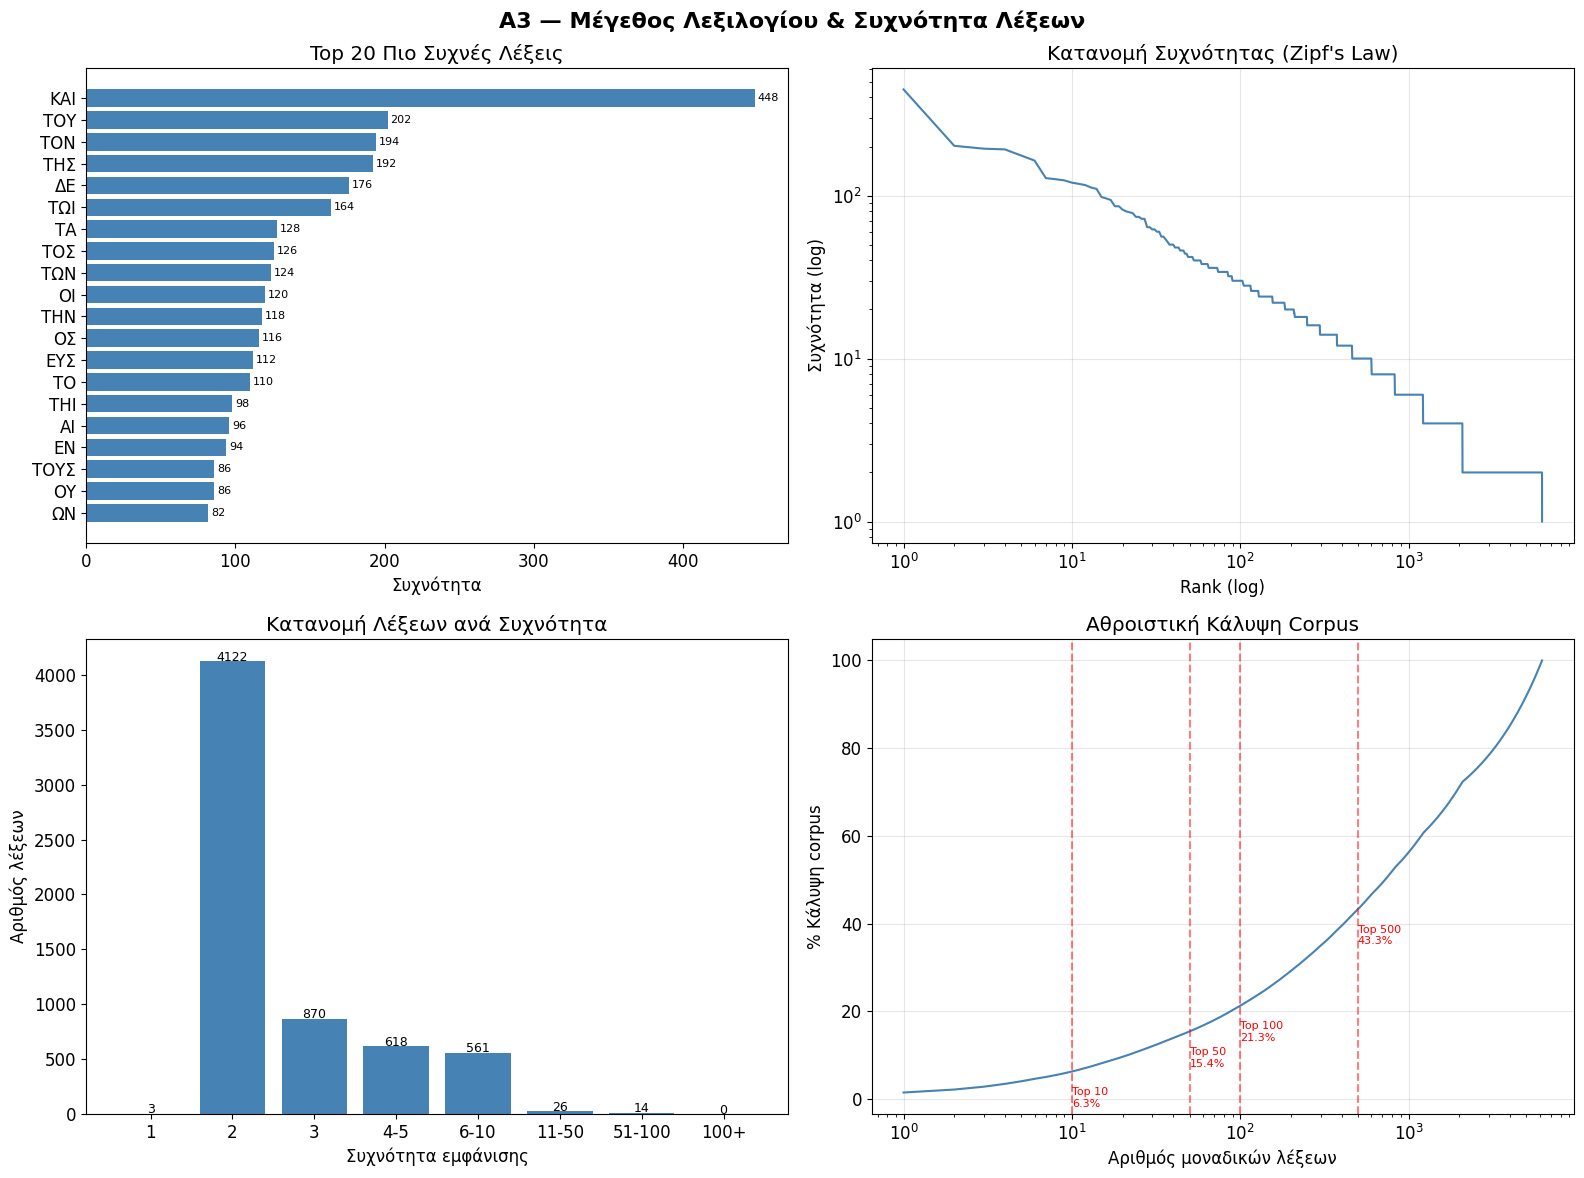

Συνολικά tokens:          29784
Μοναδικές λέξεις:         6214
Hapax legomena (freq=1):  3
Top 10 καλύπτουν:         6.3% του corpus
Top 50 καλύπτουν:         15.4% του corpus
Type-Token Ratio:         0.209


In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'

# Build data
all_segments = segmenter.segment_all(transcripts)
all_words = [word for words in all_segments.values() for word in words]
word_freq = Counter(all_words)
sorted_freqs = sorted(word_freq.values(), reverse=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Α3 — Μέγεθος Λεξιλογίου & Συχνότητα Λέξεων', fontsize=16, fontweight='bold')

# --- Plot 1: Top 20 most frequent words ---
ax1 = axes[0, 0]
top20 = word_freq.most_common(20)
words, counts = zip(*top20)
bars = ax1.barh(words[::-1], counts[::-1], color='steelblue')
ax1.set_title('Top 20 Πιο Συχνές Λέξεις')
ax1.set_xlabel('Συχνότητα')
for bar, count in zip(bars, counts[::-1]):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=8)

# --- Plot 2: Zipf's Law ---
ax2 = axes[0, 1]
ax2.plot(range(1, len(sorted_freqs)+1), sorted_freqs, color='steelblue')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Κατανομή Συχνότητας (Zipf's Law)")
ax2.set_xlabel('Rank (log)')
ax2.set_ylabel('Συχνότητα (log)')
ax2.grid(True, alpha=0.3)

# --- Plot 3: Words per frequency bin ---
ax3 = axes[1, 0]
freq_bins  = [1, 2, 3, 5, 10, 50, 100, 500]
bin_labels = ['1', '2', '3', '4-5', '6-10', '11-50', '51-100', '100+']
bin_counts = [sum(1 for c in word_freq.values() if freq_bins[i] <= c < freq_bins[i+1])
              for i in range(len(freq_bins)-1)]
bin_counts.append(sum(1 for c in word_freq.values() if c >= freq_bins[-1]))
ax3.bar(bin_labels, bin_counts, color='steelblue')
ax3.set_title('Κατανομή Λέξεων ανά Συχνότητα')
ax3.set_xlabel('Συχνότητα εμφάνισης')
ax3.set_ylabel('Αριθμός λέξεων')
for i, count in enumerate(bin_counts):
    ax3.text(i, count + 5, str(count), ha='center', fontsize=9)

# --- Plot 4: Cumulative coverage ---
ax4 = axes[1, 1]
cumsum = np.cumsum(sorted_freqs)
pct_coverage = cumsum / cumsum[-1] * 100
ax4.plot(range(1, len(pct_coverage)+1), pct_coverage, color='steelblue')
for n in [10, 50, 100, 500]:
    ax4.axvline(x=n, color='red', linestyle='--', alpha=0.5)
    ax4.text(n, pct_coverage[n-1] - 8, f'Top {n}\n{pct_coverage[n-1]:.1f}%',
             fontsize=8, color='red', ha='left')
ax4.set_title('Αθροιστική Κάλυψη Corpus')
ax4.set_xlabel('Αριθμός μοναδικών λέξεων')
ax4.set_ylabel('% Κάλυψη corpus')
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('a3_vocabulary.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f"Συνολικά tokens:          {len(all_words)}")
print(f"Μοναδικές λέξεις:         {len(word_freq)}")
print(f"Hapax legomena (freq=1):  {sum(1 for c in word_freq.values() if c == 1)}")
print(f"Top 10 καλύπτουν:         {pct_coverage[9]:.1f}% του corpus")
print(f"Top 50 καλύπτουν:         {pct_coverage[49]:.1f}% του corpus")
print(f"Type-Token Ratio:         {len(word_freq)/len(all_words):.3f}")

## Α4 — Κύρια Ονόματα

Για την αναγνώριση κύριων ονομάτων χρησιμοποιήσαμε το μοντέλο **UGARIT/grc-ner-bert**,
εκπαιδευμένο σε αρχαίο ελληνικό κείμενο. Εφαρμόζουμε NER σε κάθε επιγραφή και
κρατάμε μόνο οντότητες τύπου `PER` με score ≥ 0.75 και μήκος ≥ 5 χαρακτήρες.

Ο προσδιορισμός φύλου γίνεται με **ευρετικό κανόνα καταλήξεων**:
- Αρσενικά: `-ΟΣ`, `-ΗΣ`, `-ΑΣ`, `-ΩΝ`
- Θηλυκά: `-Η`, `-Α`, `-Ω`, `-ΙΑ`, `-ΕΙΑ`, `-ΙΣ`

### Αποτελέσματα

Εντοπίστηκαν **159 μοναδικά αρσενικά** και **22 μοναδικά θηλυκά** ονόματα —
αναλογία 7:1 υπέρ των αρσενικών. Η ανισορροπία αυτή είναι **ιστορικά αναμενόμενη**:
οι τιμητικές επιγραφές της ελληνιστικής περιόδου τιμούν κατά κύριο λόγο άνδρες
(άρχοντες, πρεσβευτές, ευεργέτες). Τα θηλυκά ονόματα εμφανίζονται σχεδόν
αποκλειστικά σε επιτύμβιες επιγραφές.

### Περιορισμοί

**1. Εξάρτηση από τμηματοποίηση**: Η απόδοση του NER εξαρτάται από την ποιότητα
της τμηματοποίησης (Α2). Λανθασμένοι διαχωρισμοί (π.χ. `ΗΡΑΚΛ` + `ΕΙΔΗΣ` αντί
`ΗΡΑΚΛΕΙΔΗΣ`) οδηγούν σε αποτυχία αναγνώρισης, ανεξάρτητα από την ποιότητα του NER.

**2. Artifacts τμηματοποίησης στα θηλυκά**: Ονόματα όπως `ΓΟΡΓΙΟΥΑ` είναι πιθανά
artifacts κακής τμηματοποίησης. Το `ΑΥΤΟΚΡΑΤΟΡΑ` είναι αιτιατική του "αυτοκράτωρ",
όχι κύριο όνομα. Αυτά τα σφάλματα επηρεάζουν κυρίως τα θηλυκά λόγω του μικρού
δείγματος.

**3. Ευρετικό φύλου**: Ο κανόνας καταλήξεων δεν καλύπτει εξαιρέσεις —
π.χ. `ΑΝΤΙΝΟΩ` (αρσενικό) ταξινομείται ως θηλυκό λόγω της κατάληξης `-Ω`.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7100.70it/s]


Αρσενικά: 159 μοναδικά | Θηλυκά: 22 μοναδικά
Top 10 M: [('ΔΙΟΝΥΣΙΟΣ', 16), ('ΚΡΑΤΗΣ', 16), ('ΗΡΑΚΛΕΙΔΗΣ', 12), ('ΣΩΚΡΑΤΗΣ', 8), ('ΘΕΟΦΙΛΟΣ', 8), ('ΑΛΕΞΑΝΔΡΟΣ', 8), ('ΑΠΟΛΛΩΝΙΟΣ', 8), ('ΑΓΑΘΟΚΛΗΣ', 6), ('ΦΙΛΩΝΟΣ', 6), ('ΔΗΜΗΤΡΙΟΣ', 6)]
Top 10 F: [('ΕΡΜΙΟΝΗ', 2), ('ΑΝΤΙΓΟΝΩ', 2), ('ΥΑΚΙΝΘΩ', 2), ('ΑΘΗΝΑ', 2), ('ΠΑΜΒΩ', 2), ('ΓΟΡΓΙΟΥΑ', 2), ('ΔΙΟΣΚΟΡΩ', 2), ('ΙΣΙΔΩ', 2), ('ΕΥΠΟΡΙΩΝΑ', 2), ('ΑΡΙΣΤΩΝΑ', 2)]


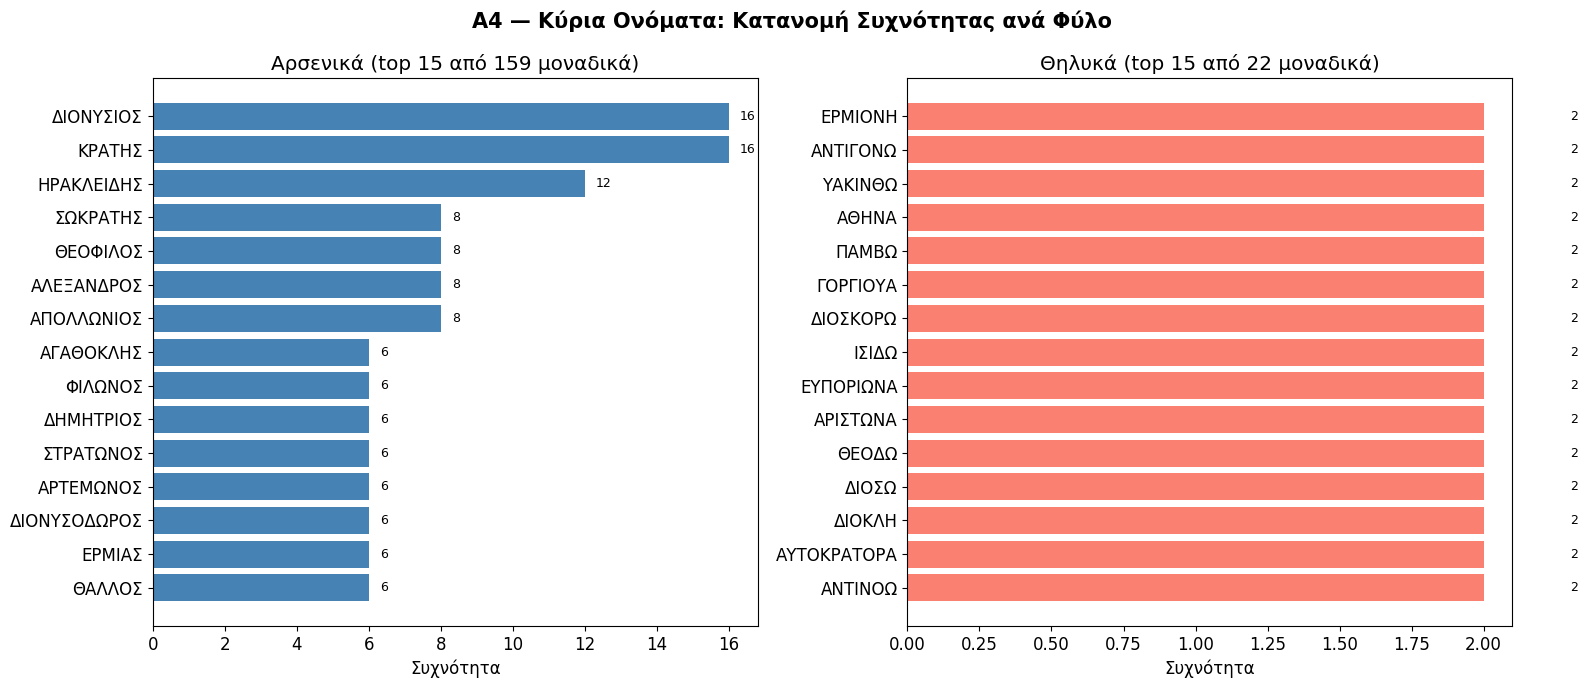

In [15]:
# ── 1. NER model ──────────────────────────────────────────────────────────────
ner = pipeline('ner', model="UGARIT/grc-ner-bert", aggregation_strategy='first')

# ── 2. Gender by endings ──────────────────────────────────────────────────────
def get_gender(t):
    for e in ["ΟΣ", "ΗΣ", "ΑΣ", "ΩΝ"]:
        if t.endswith(e): return "M"
    for e in ["ΕΙΑ", "ΙΑ", "ΙΣ", "Η", "Ω", "Α"]:
        if t.endswith(e): return "F"
    return "U"

# ── 3. Run NER on all inscriptions ────────────────────────────────────────────
all_names = {"M": [], "F": [], "U": []}

for ins_id, tokens in all_segments.items():
    text = " ".join(t.lower() for t in tokens)
    try:
        results = ner(text)
        for r in results:
            if r['entity_group'] == 'PER' and r['score'] >= 0.75:
                name = r['word'].upper().replace(' ', '')
                if len(name) >= 5:
                    all_names[get_gender(name)].append(name)
    except Exception as e:
        print(f"NER failed on {ins_id}: {e}")
        continue

masc_freq = Counter(all_names["M"])
fem_freq  = Counter(all_names["F"])
print(f"Αρσενικά: {len(masc_freq)} μοναδικά | Θηλυκά: {len(fem_freq)} μοναδικά")
print(f"Top 10 M: {masc_freq.most_common(10)}")
print(f"Top 10 F: {fem_freq.most_common(10)}")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Α4 — Κύρια Ονόματα: Κατανομή Συχνότητας ανά Φύλο',
             fontsize=15, fontweight='bold')

for ax, freq, color, label in [
    (axes[0], masc_freq, 'steelblue', 'Αρσενικά'),
    (axes[1], fem_freq,  'salmon',    'Θηλυκά')
]:
    if freq:
        names, counts = zip(*freq.most_common(15))
        ax.barh(names[::-1], counts[::-1], color=color)
        ax.set_title(f'{label} (top 15 από {len(freq)} μοναδικά)')
        ax.set_xlabel('Συχνότητα')
        for bar, c in zip(ax.patches, counts[::-1]):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    str(c), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('a4_names.png', dpi=150, bbox_inches='tight')
plt.show()

## Α5 — Ομαδοποίηση Επιγραφών & Θεματική Ανάλυση

### Pipeline

1. **Corpus**: Κατασκευάζουμε ένα corpus από τις τμηματοποιημένες λέξεις (Α2),
   φιλτράροντας fragments μήκους < 3 χαρακτήρων.

2. **TF-IDF**: Μετατρέπουμε κάθε επιγραφή σε διάνυσμα TF-IDF (448 × 4621).
   Το TF-IDF δίνει υψηλό βάρος σε λέξεις που είναι χαρακτηριστικές μιας
   επιγραφής αλλά σπάνιες στο υπόλοιπο corpus.

3. **KMeans**: Ομαδοποιούμε τις επιγραφές με KMeans. Επιλέγουμε **k=7**
   βάσει ισορροπίας clusters δοκιμάζοντας το silhouette analysis από k=2 εώς και κ=20. Αυτό έδωσε
   χαμηλά scores (< 0.06) λόγω της ομοιόμορφης επιγραφικής γλώσσας,
   οπότε επιλέξαμε pragmatically τον πιο ισορροπημένο k.

4. **UMAP**: Απεικονίζουμε τα clusters σε 2D για οπτική επιθεώρηση.

### Ερωτήματα

- **α. Δομή κειμένου**: Τα clusters αντιστοιχούν μερικώς σε επιγραφικές
  κατηγορίες (ψηφίσματα, επιτύμβιες, συμβόλαια).

- **β. Επαναλαμβανόμενες φράσεις**: Εντοπίστηκαν μέσω word n-grams (2 και
  3 λέξεων) — ισχυρές φόρμουλες κυρίως στο Cluster 1 (ΤΩΙ ΔΗΜΩΙ ×52,
  ΔΗΜΟΝ ΤΟΝ ΑΘΗΝΑΙΩΝ ×14).

- **γ. Θεματική ανάλυση**: Εφαρμόσαμε LDA (7 topics) σε CountVectorizer
  matrix με αφαίρεση stopwords — εντοπίστηκαν 4 διακριτές κατηγορίες:
  ψηφίσματα, συμβόλαια, οικονομικές πράξεις, επιτύμβιες.

In [38]:
# ── 1. Build corpus from segmented words ──────────────────────────────────────
corpus = {
    key: ' '.join(w for w in words if len(w) >= 3)
    for key, words in all_segments.items()
}

In [39]:
# ── 2. TF-IDF Vectorization ───────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

keys = list(corpus.keys())
texts = [corpus[k] for k in keys]
tfidf_matrix = vectorizer.fit_transform(texts)

print(f"Inscriptions: {tfidf_matrix.shape[0]}")
print(f"Features (unique words): {tfidf_matrix.shape[1]}")

Inscriptions: 448
Features (unique words): 5907


k=2: silhouette=0.0065
k=3: silhouette=0.0104
k=4: silhouette=0.0112
k=5: silhouette=0.0147
k=6: silhouette=0.0159
k=7: silhouette=0.0178
k=8: silhouette=0.0205
k=9: silhouette=0.0177
k=10: silhouette=0.0246
k=11: silhouette=0.0293
k=12: silhouette=0.0281
k=13: silhouette=0.0308
k=14: silhouette=0.0374
k=15: silhouette=0.0354
k=16: silhouette=0.0458
k=17: silhouette=0.0445
k=18: silhouette=0.0370
k=19: silhouette=0.0479
k=20: silhouette=0.0548

Best k: 20 (score=0.0548)


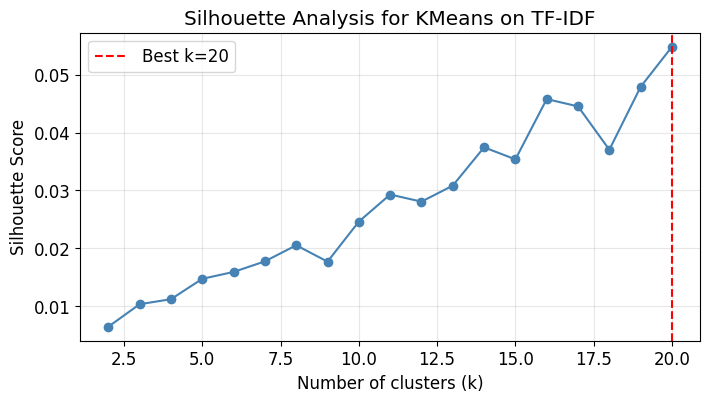

In [40]:
# ── 3. Silhouette analysis ────────────────────────────────────────────────────
silhouette_scores = {}
for k in range(2, 21):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, labels, sample_size=300)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette={score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k} (score={silhouette_scores[best_k]:.4f})")

plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()),
         marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for KMeans on TF-IDF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
km = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_labels = km.fit_predict(tfidf_matrix)

inscription_clusters = {key: int(cluster_labels[i]) for i, key in enumerate(keys)}

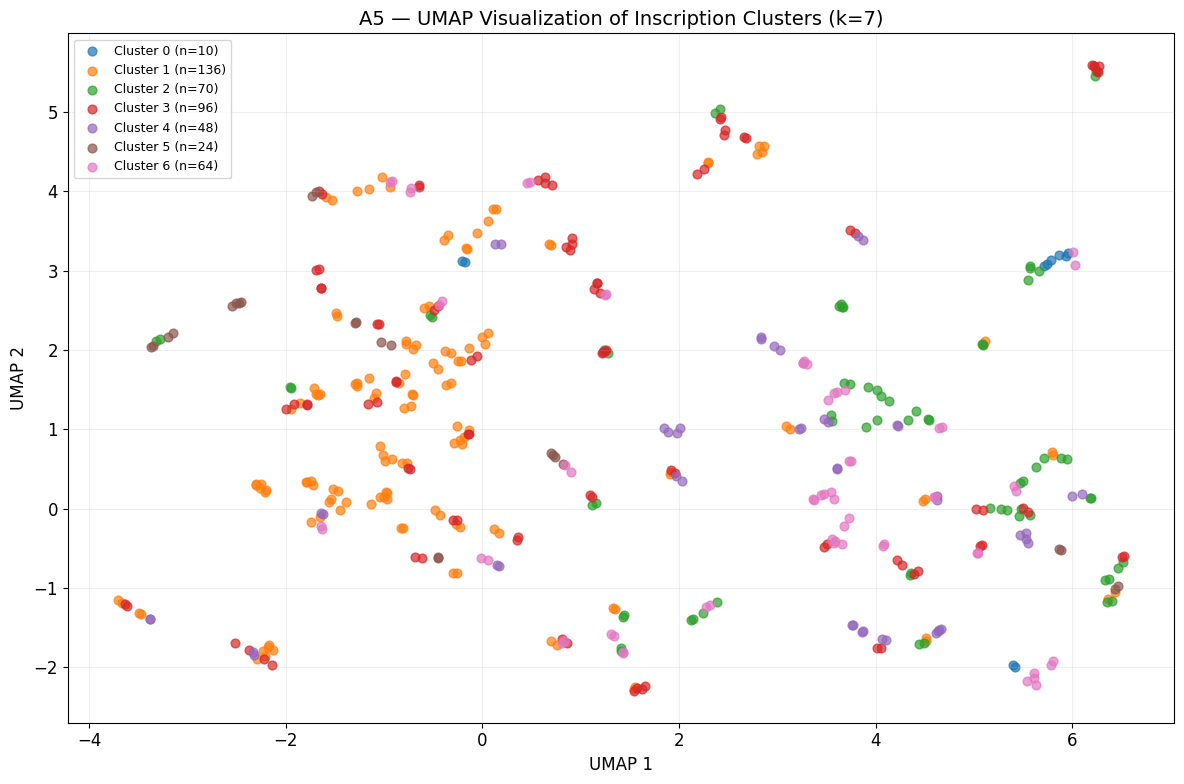

In [42]:
# ── UMAP reduction to 2D for visualization ────────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(tfidf_matrix.toarray())

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = plt.cm.tab10.colors

plt.figure(figsize=(12, 8))
for c in range(7):
    mask = cluster_labels == c
    plt.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=[colors[c]], label=f'Cluster {c} (n={mask.sum()})',
        alpha=0.7, s=40
    )

plt.title('Α5 — UMAP Visualization of Inscription Clusters (k=7)', fontsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('a5_umap.png', dpi=150, bbox_inches='tight')
plt.show()


In [43]:
feature_names = vectorizer.get_feature_names_out()

for c in range(7):
    cluster_indices = [i for i, l in enumerate(cluster_labels) if l == c]
    cluster_tfidf = tfidf_matrix[cluster_indices].mean(axis=0)
    top_indices = np.asarray(cluster_tfidf).flatten().argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Cluster {c} (n={len(cluster_indices)}): {' | '.join(top_words)}")

Cluster 0 (n=10): διον | πολε | γυμνασιαρχο | διοκ | χρυς | ογο | ιμη | ιωνα | οισι | χωελ
Cluster 1 (n=136): και | τον | της | τωι | τηι | του | δημωι | των | τους | την
Cluster 2 (n=70): ρος | ευς | μαρα | τρι | ιος | σιος | μος | ζωσιμος | δης | νος
Cluster 3 (n=96): και | οιαν | ανι | την | της | ελευθερι | τωνε | χαριν | σιαν | νει
Cluster 4 (n=48): ους | αχα | του | ευο | ρνε | τιος | ιος | μοθ | πολλ | θευς
Cluster 5 (n=24): ναι | ανο | ηνα | ειδ | οδω | ρεας | αυτοι | μενας | οσιον | οτον
Cluster 6 (n=64): επι | αρχοντος | ηφι | κος | σοδ | ντος | θεο | χαρ | τρα | παλ


### α. Αντιστοιχούν τα clusters σε ομοιότητες στη δομή κειμένου;

Ναι, μερικώς. Παρά τα χαμηλά silhouette scores, τα clusters αντικατοπτρίζουν
διακριτές επιγραφικές κατηγορίες:

- **Cluster 1** (n=136): Κυριαρχούν λέξεις όπως ΚΑΙ, ΔΗΜΩΙ, ΤΩΙ — τυπική
  γλώσσα **ψηφισμάτων** της εκκλησίας του δήμου.
- **Cluster 2** (n=70): Κυριαρχούν καταλήξεις κύριων ονομάτων (ΙΟΣ, ΔΗΣ, ΝΟΣ)
  — πιθανώς **επιτύμβιες** επιγραφές ή αναθηματικές.
- **Cluster 3** (n=96): Εμφανίζεται η λέξη ΕΛΕΥΘΕΡΙ και ΧΑΡΙΝ —
  υποδηλώνει **απελευθερωτικές** επιγραφές.
- **Cluster 6** (n=64): Η φράση ΑΡΧΟΝΤΟΣ + ΕΠΙ είναι τυπικός **χρονολογικός
  τύπος** ("επί άρχοντος...") που εμφανίζεται σε επίσημα έγγραφα.

Συμπέρασμα: τα clusters αντιστοιχούν **μερικώς** σε δομικές ομοιότητες —
οι μεγάλες κατηγορίες επιγραφών (ψηφίσματα, επιτύμβιες, απελευθερωτικές)
διαχωρίζονται, αλλά η επικάλυψη είναι σημαντική λόγω της ομοιόμορφης
επιγραφικής γλώσσας.

In [ ]:
for c in range(7):
    cluster_indices = [i for i, l in enumerate(cluster_labels) if l == c]
    
    # Get all bigrams and trigrams for this cluster
    bigrams = []
    trigrams = []
    for idx in cluster_indices:
        words = [w for w in all_segments[keys[idx]] if len(w) >= 3]
        bigrams += [' '.join(words[i:i+2]) for i in range(len(words)-1)]
        trigrams += [' '.join(words[i:i+3]) for i in range(len(words)-2)]
    
    top_bigrams = Counter(bigrams).most_common(3)
    top_trigrams = Counter(trigrams).most_common(3)
    print(f"\nCluster {c} (n={len(cluster_indices)}):")
    print(f" Word Bigrams:  {top_bigrams}")
    print(f" Word Trigrams: {top_trigrams}")


Cluster 0 (n=10):
 Word Bigrams:  [('ΑΡΧ ΜΕΝΝΕΑΣ', 2), ('ΜΕΝΝΕΑΣ ΖΩΒΑ', 2), ('ΖΩΒΑ ΣΤΙ', 2)]
 Word Trigrams: [('ΑΡΧ ΜΕΝΝΕΑΣ ΖΩΒΑ', 2), ('ΜΕΝΝΕΑΣ ΖΩΒΑ ΣΤΙ', 2), ('ΖΩΒΑ ΣΤΙ ΜΟΣ', 2)]

Cluster 1 (n=136):
 Word Bigrams:  [('ΤΩΙ ΔΗΜΩΙ', 52), ('ΕΠΑΙ ΝΕΣ', 24), ('ΔΗΜΟΝ ΤΟΝ', 20)]
 Word Trigrams: [('ΔΗΜΟΝ ΤΟΝ ΑΘΗΝΑΙΩΝ', 14), ('ΟΡΚΟΣ ΚΑΙΤΑΣ ΣΥΝΘΗΚΑΣ', 12), ('ΤΩΙ ΔΗΜΩΙ ΤΩΙ', 10)]

Cluster 2 (n=70):
 Word Bigrams:  [('ΩΣΙ ΜΟΣ', 10), ('ΟΔΩ ΡΟΣ', 10), ('ΚΑΡΠ ΟΔΩ', 10)]
 Word Trigrams: [('ΚΟΡΑΤ ΤΙΚΟ ΣΟΚ', 4), ('ΣΩΤΑ ΤΡΙ ΝΕΜΕ', 4), ('ΣΑΣ ΚΛΗ ΠΙΑ', 4)]

Cluster 3 (n=96):
 Word Bigrams:  [('ΣΤΟ ΕΡΓΟΝ', 6), ('ΤΑΥΤΗΝ ΤΗΝ', 4), ('ΦΛΑ ΜΜΕ', 4)]
 Word Trigrams: [('ΑΝΙ ΕΛΕΥΘΕΡΙ ΟΙΑΝ', 4), ('ΣΠΑ ΝΤΑ ΧΗΙ', 4), ('ΑΝΟΙ ΤΗΝ ΕΡΓΑΣΙΑΝ', 4)]

Cluster 4 (n=48):
 Word Bigrams:  [('ΜΟΘ ΕΤΑΙ', 10), ('ΑΧΑ ΡΝΕ', 8), ('ΦΛΥ ΕΥΣ', 6)]
 Word Trigrams: [('ΟΝΑΠΟΤΟ ΥΜΕ ΓΙΣ', 4), ('ΥΜΕ ΓΙΣ ΤΟΥΕΙΣ', 4), ('ΘΕΣ ΜΟΘ ΕΤΑΙ', 4)]

Cluster 5 (n=24):
 Word Bigrams:  [('ΟΔΩ ΡΟΣ', 6), ('ΟΤΟΝ ΕΙΔ', 4), ('ΕΙΔ ΟΔΩ', 4)]
 Word Trigrams: [('ΟΤΟ

### β. Περιλαμβάνουν τα clusters επαναλαμβανόμενες φράσεις;

Ναι, ιδιαίτερα στα clusters με καλύτερη δομή. Αναζητήσαμε επαναλαμβανόμενες
**φράσεις 2 και 3 λέξεων** (word n-grams) ανά cluster:

- **Cluster 1** (n=136): Εμφανίζονται σαφείς επαναλαμβανόμενες φράσεις:
  - `ΤΩΙ ΔΗΜΩΙ` (52 φορές) — τυπική φράση ψηφισμάτων ("στον δήμο")
  - `ΕΠΑΙΝΕΣ` (24) — τυπικός επαινετικός τύπος ("να επαινεθεί")
  - `ΔΗΜΟΝ ΤΟΝ ΑΘΗΝΑΙΩΝ` (14) — αναφορά στον αθηναϊκό δήμο
  - `ΟΡΚΟΣ ΚΑΙΤΑΣ ΣΥΝΘΗΚΑΣ` (12) — ορκωμοτικός τύπος συνθηκών

  Αυτές οι φράσεις επιβεβαιώνουν ότι το cluster αντιστοιχεί σε
  **τυποποιημένα ψηφίσματα** με σταθερές επιγραφικές φόρμουλες.

- **Cluster 6** (n=64): Οι φράσεις `ΤΥΧΗΙ ΕΠΙ ΑΡΧΟΝΤΟΣ` και `ΣΤΡΑΤΗΓΟΥ ΝΤΟΣ ΕΠΙ`
  είναι τυπικοί **χρονολογικοί τύποι** επίσημων εγγράφων.

- **Clusters 0, 2, 4, 5**: Οι φράσεις περιέχουν κυρίως
  **fragments τμηματοποίησης** — δεν εντοπίζονται αξιόπιστες επαναλαμβανόμενες φράσεις.

**Συμπέρασμα**: Επαναλαμβανόμενες φράσεις εντοπίζονται κυρίως στο Cluster 1,
όπου η τυποποιημένη γλώσσα των ψηφισμάτων δημιουργεί σταθερές φόρμουλες.

In [ ]:
# ── 1. Build LDA-ready corpus (no stopwords, min length 4) ───────────────────
greek_stopwords = {'ΚΑΙ', 'ΤΟΝ', 'ΤΗΝ', 'ΤΟΥ', 'ΤΗΣ', 'ΤΩΝ', 'ΤΩΙ', 'ΤΗΙ',
                   'ΤΟΙ', 'ΤΑ', 'ΤΟ', 'ΤΗ', 'ΔΕ', 'ΕΝ', 'ΕΚ', 'ΕΙΣ', 'ΕΠΙ',
                   'ΑΠΟ', 'ΟΙ', 'ΑΙ', 'ΟΥ', 'ΜΗ', 'ΑΝ', 'ΤΕ', 'ΓΑΡ', 'ΟΤΙ'}

lda_corpus = {
    key: ' '.join(w for w in words if len(w) >= 4 and w not in greek_stopwords)
    for key, words in all_segments.items()
}

# ── 2. TF vectorizer for LDA (LDA needs raw counts, not TF-IDF) ──────────────

count_vectorizer = CountVectorizer(min_df=2, max_df=0.9)
lda_keys = list(lda_corpus.keys())
lda_texts = [lda_corpus[k] for k in lda_keys]
count_matrix = count_vectorizer.fit_transform(lda_texts)

print(f"LDA matrix: {count_matrix.shape}")

# ── 3. Fit LDA with 7 topics (matching our clusters) ─────────────────────────
lda = LatentDirichletAllocation(n_components=7, random_state=42, max_iter=20)
lda.fit(count_matrix)

# ── 4. Print top words per topic ──────────────────────────────────────────────
lda_features = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[::-1][:10]
    top_words = [lda_features[i] for i in top_indices]
    print(f"Topic {topic_idx}: {' | '.join(top_words)}")

LDA matrix: (448, 4621)
Topic 0: αθηναιων | δημωι | δημον | επειδη | καις | κατα | δημου | αυτον | προστ | τους
Topic 1: τοις | αθηναι | αθηναιων | θηναι | δημωι | πρυταν | κατα | εντωι | ορκος | καιτας
Topic 2: ζωσιμος | εργον | σκαι | κλης | φαντ | ιππος | αρχοντος | επει | μισθωση | βους
Topic 3: εται | μαρα | μηθυ | μναι | πολε | τους | κλης | δημητριος | δοτος | φιλητος
Topic 4: διονυσιος | θμον | τους | τιος | φιλος | ευκαρπος | αρχοντος | συμφ | στης | δημητριος
Topic 5: δημωι | αθηναιων | τους | κατα | δημου | σιος | περι | ειπεν | προεδρων | δημον
Topic 6: τους | μηκος | τοις | ντος | πανταχηι | τοδε | τουσδε | σκαι | αρχοντος | παρα


### γ. Εμφανίζονται συγκεκριμένα θέματα σε κάθε cluster;

Εφαρμόσαμε **LDA (Latent Dirichlet Allocation)** με 7 topics στο corpus,
χρησιμοποιώντας CountVectorizer (raw counts, όπως απαιτεί το LDA) με
αφαίρεση stopwords και ελάχιστο μήκος λέξης 4 χαρακτήρες.

| Topic | Κύριες Λέξεις | Ερμηνεία |
|---|---|---|
| 0 | ΑΘΗΝΑΙΩΝ, ΔΗΜΩΙ, ΕΠΕΙΔΗ | Αθηναϊκά ψηφίσματα |
| 1 | ΠΡΥΤΑΝΕΙΣ, ΟΡΚΟΣ, ΚΑΙΤΑΣ | Ψηφίσματα με όρκους/συνθήκες |
| 2 | ΖΩΣΙΜΟΣ, ΕΡΓΟΝ, ΜΙΣΘΩΣΗ, ΒΟΥΣ | Συμβόλαια/μισθώσεις |
| 3 | ΜΝΑΙ, ΔΗΜΗΤΡΙΟΣ, ΦΙΛΗΤΟΣ | Οικονομικές/απελευθερωτικές πράξεις |
| 4 | ΔΙΟΝΥΣΙΟΣ, ΕΥΚΑΡΠΟΣ, ΦΙΛΟΣ | Προσωπικές τιμητικές/επιτύμβιες |
| 5 | ΕΙΠΕΝ, ΠΡΟΕΔΡΩΝ, ΠΕΡΙ | Πρακτικά συνελεύσεων |
| 6 | ΠΑΝΤΑΧΗΙ, ΤΟΔΕ, ΑΡΧΟΝΤΟΣ | Επίσημα χρονολογημένα έγγραφα |

**Παρατήρηση**: Τα Topics 0, 1, 5 εμφανίζουν επικάλυψη — αντικατοπτρίζουν
υποκατηγορίες της ίδιας επιγραφικής κατηγορίας (ψηφίσματα), επιβεβαιώνοντας
ότι η πλειοψηφία του corpus αποτελείται από **τυποποιημένα αθηναϊκά ψηφίσματα**.

**Συμπέρασμα**: Το LDA αποκαλύπτει θεματική δομή στο corpus παρά την
επικάλυψη — εντοπίζει τουλάχιστον 4 διακριτές κατηγορίες επιγραφών
(ψηφίσματα, συμβόλαια, οικονομικές πράξεις, επιτύμβιες).